# Taller: Opciones Europeas — Modelo Markov-Modulado
**Julián Alejandro Archila Caro**

Ejercicios 1 – 6 y 10.

In [27]:
import numpy as np

## Ejercicio 1 — Función característica

In [28]:
def char_func_markov(z, T, r0, r1, sigma0, sigma1, lam0, lam1, regime=0):
    """
    Función característica del log-precio bajo Q
    (VERSIÓN DEFINITIVA: Estable ante overflow y división por cero).
    """
    z = np.asarray(z, dtype=np.complex128)

    mu_hat0 = r0 - 0.5 * sigma0**2
    mu_hat1 = r1 - 0.5 * sigma1**2

    mu_plus    = (mu_hat0 + mu_hat1) / 2
    mu_minus   = (mu_hat0 - mu_hat1) / 2
    sigma_plus  = (sigma0**2 + sigma1**2) / 4
    sigma_minus = (sigma0**2 - sigma1**2) / 4
    lam_plus  = (lam0 + lam1) / 2
    lam_minus = (lam0 - lam1) / 2

    rho_plus  = 1j * z * mu_plus  - sigma_plus  * z**2 - lam_plus
    rho_minus = 1j * z * mu_minus - sigma_minus * z**2 - lam_minus

    D = rho_minus**2 + lam0 * lam1
    sqrt_D = np.sqrt(D)

    # --- PARCHE 1: Evitar división por cero de forma segura ---
    safe_sqrt_D = np.where(sqrt_D == 0, 1.0, sqrt_D)

    if regime == 0:
        c = (rho_minus + lam0) / safe_sqrt_D
        # Límite teórico exacto si sqrt_D == 0
        limit_val = np.exp(T * rho_plus) * (1.0 + (rho_minus + lam0) * T)
    else:
        c = -(rho_minus - lam1) / safe_sqrt_D
        # Límite teórico exacto si sqrt_D == 0
        limit_val = np.exp(T * rho_plus) * (1.0 - (rho_minus - lam1) * T)

    # --- PARCHE 2: Formulación estable para evitar (0.0 * inf = nan) ---
    term1 = 0.5 * np.exp(T * (rho_plus + sqrt_D)) * (1.0 + c)
    term2 = 0.5 * np.exp(T * (rho_plus - sqrt_D)) * (1.0 - c)
    stable_phi = term1 + term2

    # Retornamos el límite si D=0, o la función estable en cualquier otro caso
    return np.where(sqrt_D == 0, limit_val, stable_phi)

## Ejercicio 2 — Verificación

(a) Caso sin cambio de régimen ($\lambda_0=\lambda_1=0$): debe reducirse a la f. característica de un Browniano con drift.

(b) Condición inicial: $\varphi_i(z,0)=1$.

(c) Primer momento: $-i\,\varphi'_i(0,T) = \mathbb{E}^{\mathbb{Q}}_i[X^{\mathbb{Q}}_T]$. Para la cadena de dos estados con probabilidades estacionarias $\pi_0=\lambda_1/(\lambda_0+\lambda_1)$, $\pi_1=1-\pi_0$,

$$\mathbb{E}^{\mathbb{Q}}_i[X^{\mathbb{Q}}_T] = (\pi_0\hat\mu^{\mathbb{Q}}_0 + \pi_1\hat\mu^{\mathbb{Q}}_1)\,T + \pi_{1-i}\,\tfrac{1-e^{-(\lambda_0+\lambda_1)T}}{\lambda_0+\lambda_1}\,(\hat\mu^{\mathbb{Q}}_i - \hat\mu^{\mathbb{Q}}_{1-i}).$$

In [29]:
# ---------- (a) Sin cambio de regimen: comparacion con Browniano con drift ----------
z_test = np.linspace(-5, 5, 200) + 0j
T_test = 1.0
r, sigma = 0.05, 0.2

phi_mm = char_func_markov(z_test, T_test, r, r, sigma, sigma,
                          0.0, 0.0, regime=0)
mu_hat = r - 0.5 * sigma**2
phi_bs = np.exp(1j * z_test * mu_hat * T_test
                - 0.5 * sigma**2 * z_test**2 * T_test)

print("Error max (sin regimen):", np.max(np.abs(phi_mm - phi_bs)))

# ---------- (b) Condicion inicial phi(z, 0) = 1 ----------
phi_0 = char_func_markov(z_test, 0.0, 0.05, 0.03,
                         0.2, 0.4, 2.0, 3.0, regime=0)
print("Error max (t=0):", np.max(np.abs(phi_0 - 1.0)))

# ---------- (c) Primer momento: -i * phi'(0, T) vs. E[X_T] analitico ----------
T, r0, r1 = 1.0, 0.05, 0.03
sigma0, sigma1 = 0.2, 0.4
lam0, lam1 = 2.0, 3.0

mu0 = r0 - 0.5 * sigma0**2
mu1 = r1 - 0.5 * sigma1**2
pi0 = lam1 / (lam0 + lam1)
pi1 = 1 - pi0
mu_stat = pi0 * mu0 + pi1 * mu1
transient = (1 - np.exp(-(lam0 + lam1) * T)) / (lam0 + lam1)

h = 1e-5
for regime in (0, 1):
    mu_i = mu0 if regime == 0 else mu1
    mu_j = mu1 if regime == 0 else mu0
    pi_j = pi1 if regime == 0 else pi0
    E_analytic = mu_stat * T + pi_j * transient * (mu_i - mu_j)

    phi_p = char_func_markov(np.array([+h]), T, r0, r1, sigma0, sigma1, lam0, lam1, regime)[0]
    phi_m = char_func_markov(np.array([-h]), T, r0, r1, sigma0, sigma1, lam0, lam1, regime)[0]
    E_fd = float(np.real(-1j * (phi_p - phi_m) / (2 * h)))

    print(f"regimen {regime}: E[X_T] analitico = {E_analytic: .8f}, "
          f"-i*phi'(0,T) = {E_fd: .8f}, error = {abs(E_fd - E_analytic):.2e}")

Error max (sin regimen): 0.0
Error max (t=0): 1.1102230246251565e-16
regimen 0: E[X_T] analitico =  0.00435688, -i*phi'(0,T) =  0.00435688, error = 1.38e-14
regimen 1: E[X_T] analitico = -0.01153532, -i*phi'(0,T) = -0.01153532, error = 9.38e-14


### Interpretación del primer momento

Los errores del orden de $10^{-14}$ en ambos regímenes confirman la corrección de la función característica: la derivada numérica $-i\,\varphi'_i(0,T)$ reproduce exactamente la esperanza analítica.

La fórmula tiene dos componentes con interpretación financiera clara:

- **Término estacionario** $(\pi_0\hat\mu_0+\pi_1\hat\mu_1)T$: el drift promedio que el activo experimentaría si la cadena ya estuviera en su distribución ergódica $\pi_0=\lambda_1/(\lambda_0+\lambda_1)$.
- **Corrección transitoria** $\pi_{1-i}\,\tfrac{1-e^{-(\lambda_0+\lambda_1)T}}{\lambda_0+\lambda_1}\,(\hat\mu_i-\hat\mu_{1-i})$: captura el efecto de arrancar en un régimen particular $i$ en lugar de en el estacionario. Se desvanece a tasa $\lambda_0+\lambda_1$ cuando $T\to\infty$, consistente con la ergodicidad de la cadena.

Nótese que para el régimen 0 (baja volatilidad, $\hat\mu_0>\hat\mu_1$) el valor esperado es positivo, mientras que para el régimen 1 es negativo: el modelo penaliza el log-retorno cuando se parte de un régimen de crisis, como se espera económicamente.

## Ejercicio 3


In [30]:
import numpy as np

def carr_madan_fft(S0, T, r, sigma0, sigma1, lam0, lam1,
                   regime=0, N=4096, alpha=1.5, eta=0.25):
    """
    Valoración de calls europeas por Carr-Madan FFT
    en el modelo Markov-modulado con tasa constante r.

    Parámetros
    ----------
    S0 : float
        Precio spot inicial.
    T : float
        Vencimiento.
    r : float
        Tasa libre de riesgo constante.
    sigma0, sigma1 : float
        Volatilidades por régimen.
    lam0, lam1 : float
        Intensidades de cambio de régimen.
    regime : int
        Régimen inicial, 0 o 1.
    N : int
        Número de puntos de la FFT.
    alpha : float
        Parámetro de amortiguamiento.
    eta : float
        Paso en frecuencia.

    Retorna
    -------
    strikes : np.ndarray
        Vector de strikes.
    prices : np.ndarray
        Vector de precios call.
    """
    if N <= 0 or (N & (N - 1)) != 0:
        raise ValueError("N debe ser potencia de 2 para una FFT eficiente.")
    if alpha <= 0:
        raise ValueError("alpha debe ser positivo.")
    if eta <= 0:
        raise ValueError("eta debe ser positivo.")
    if regime not in (0, 1):
        raise ValueError("regime debe ser 0 o 1.")

    # Relación eta * dk = 2*pi/N
    dk = 2.0 * np.pi / (N * eta)
    b = 0.5 * N * dk

    # Grilla de frecuencias
    j = np.arange(N)
    nu = j * eta

    # Pesos de Simpson 1/3 con corrección Kronecker (Carr-Madan 1999):
    # 1/3, 4/3, 2/3, 4/3, 2/3, ...
    w = np.ones(N)
    w[0] = 1.0 / 3.0
    w[1::2] = 4.0 / 3.0
    w[2::2] = 2.0 / 3.0

    # Shift complejo de Carr-Madan
    z = nu - 1j * (alpha + 1.0)

    # Función característica del log-retorno x_T = ln(S_T / S_0)
    phi = char_func_markov(
        z, T, r, r, sigma0, sigma1, lam0, lam1, regime=regime
    )

    # Transformada del precio amortiguado
    denom = (alpha + 1j * nu) * (alpha + 1.0 + 1j * nu)
    psi = np.exp(-r * T) * phi / denom

    # Entrada a la FFT
    x = np.exp(1j * b * nu) * psi * eta * w

    # FFT
    y = np.fft.fft(x)

    # Como char_func_markov es la función característica del log-RETORNO
    # x_T = ln(S_T/S_0), la inversión FFT produce naturalmente precios en
    # la grilla de log-moneyness u = ln(K/S_0). Entonces:
    #   C(K) = S_0 * e^{-alpha*u} / pi * Re(y).
    # El factor S_0 proviene de factorizar el payoff
    # (S_T - K)_+ = S_0 * (exp(x_T) - K/S_0)_+.
    u = -b + j * dk
    strikes = S0 * np.exp(u)
    prices = S0 * np.exp(-alpha * u) * np.real(y) / np.pi

    # Limpieza numérica simple
    prices = np.maximum(prices, 0.0)

    # Filtrar región razonable alrededor de S0
    mask = (strikes > 0.3 * S0) & (strikes < 3.0 * S0)

    return strikes[mask], prices[mask]

In [31]:
S0, T, r = 100.0, 1.0, 0.05
sigma0, sigma1 = 0.2, 0.35
lam0, lam1 = 2.0, 3.0

K_fft, C_fft = carr_madan_fft(
    S0, T, r, sigma0, sigma1, lam0, lam1,
    regime=0, N=4096, alpha=1.5, eta=0.25
)

print("Número de strikes devueltos:", len(K_fft))
print("Primeros 5 strikes:", K_fft[:5])
print("Primeros 5 precios:", C_fft[:5])

Número de strikes devueltos: 376
Primeros 5 strikes: [30.03998262 30.2248723  30.41089993 30.59807253 30.78639713]
Primeros 5 precios: [71.42512079 71.24925154 71.07230012 70.89425988 70.71512415]


### ¿Cuántos strikes se valoran en una sola ejecución de la FFT?

**Respuesta: $N=4096$ strikes** (en general, tantos como puntos tenga la FFT).

Una llamada a `np.fft.fft(x)` con un arreglo de longitud $N$ produce los $N$ precios de la grilla de log-moneyness

$$u_j=-b+j\,\Delta k,\qquad j=0,1,\dots,N-1,$$

con $\Delta k=2\pi/(N\eta)$ y $b=N\Delta k/2$, todos en un único paso de coste $O(N\log N)$. Esta es la ventaja clave de Carr–Madan sobre la cuadratura directa, que tendría que invertir la integral una vez por cada strike.

**¿Por qué el output dice 376?** Los 4096 sí se calcularon dentro de la función; lo que pasa es que antes de retornarlos se aplica

```python
mask = (strikes > 0.3 * S0) & (strikes < 3.0 * S0)
```

para quedarse sólo con la región financieramente relevante. Con los parámetros por defecto el rango completo de la grilla llega hasta $K\approx S_0\,e^{\pm 12.6}$, es decir, strikes entre $\sim 3\times 10^{-4}\,S_0$ y $\sim 3\times 10^{5}\,S_0$, donde el integrando amortiguado es prácticamente ruido numérico. El filtro descarta esos extremos y deja 376 strikes útiles en torno a $S_0=100$ — la FFT sigue siendo de 4096 puntos.

## Ejercicio 4 — Validación contra Black–Scholes

Cuando $\lambda_0=\lambda_1=0$ y $\sigma_0=\sigma_1=\sigma$, la cadena de Markov se congela y el modelo se reduce a Black–Scholes estándar con volatilidad constante. Por lo tanto los precios obtenidos por la FFT deben coincidir, dentro del error de discretización, con la fórmula analítica

$$C^{\text{BS}}(S_0,K,T,r,\sigma)=S_0\,N(d_1)-K\,e^{-rT}\,N(d_2),\qquad d_{1,2}=\frac{\ln(S_0/K)+(r\pm\tfrac12\sigma^2)T}{\sigma\sqrt T}.$$

Usaremos los parámetros pedidos en el enunciado ($S_0=100$, $r=0.05$, $\sigma=0.2$, $T=1$), calcularemos el error absoluto máximo tanto en toda la grilla devuelta como en la región ATM ($0.7\,S_0<K<1.3\,S_0$), y graficaremos ambas curvas superpuestas.

In [32]:
import matplotlib.pyplot as plt
from scipy.stats import norm


def bs_call(S0, K, T, r, sigma):
    """Fórmula cerrada de Black-Scholes para una call europea."""
    K = np.asarray(K, dtype=float)
    sqrtT = sigma * np.sqrt(T)
    d1 = (np.log(S0 / K) + (r + 0.5 * sigma**2) * T) / sqrtT
    d2 = d1 - sqrtT
    return S0 * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)


# Parametros del enunciado
S0, T, r, sigma = 100.0, 1.0, 0.05, 0.2

K_fft, C_fft = carr_madan_fft(
    S0, T, r, sigma, sigma, 0.0, 0.0,
    regime=0, N=4096, alpha=1.5, eta=0.25,
)
C_bs = bs_call(S0, K_fft, T, r, sigma)

err_abs = np.abs(C_fft - C_bs)
mask_atm = (K_fft > 0.7 * S0) & (K_fft < 1.3 * S0)

err_max_global = err_abs.max()
err_max_atm = err_abs[mask_atm].max()
k_worst_global = K_fft[err_abs.argmax()]
k_worst_atm = K_fft[mask_atm][err_abs[mask_atm].argmax()]

print(f"Strikes evaluados:              {len(K_fft)}")
print(f"Rango de strikes:               [{K_fft.min():.2f}, {K_fft.max():.2f}]")
print(f"Error absoluto maximo (total):  {err_max_global:.4e}  en K = {k_worst_global:.4f}")
print(f"Error absoluto maximo (ATM):    {err_max_atm:.4e}  en K = {k_worst_atm:.4f}")

i_atm = np.argmin(np.abs(K_fft - S0))
print(f"\nEn K = {K_fft[i_atm]:.4f} (ATM):")
print(f"  Call FFT = {C_fft[i_atm]:.8f}")
print(f"  Call BS  = {C_bs[i_atm]:.8f}")
print(f"  Error    = {abs(C_fft[i_atm] - C_bs[i_atm]):.4e}")

Strikes evaluados:              376
Rango de strikes:               [30.04, 299.92]
Error absoluto maximo (total):  2.1708e-07  en K = 30.2249
Error absoluto maximo (ATM):    2.1708e-07  en K = 70.9204

En K = 100.0000 (ATM):
  Call FFT = 10.45058336
  Call BS  = 10.45058357
  Error    = 2.1708e-07


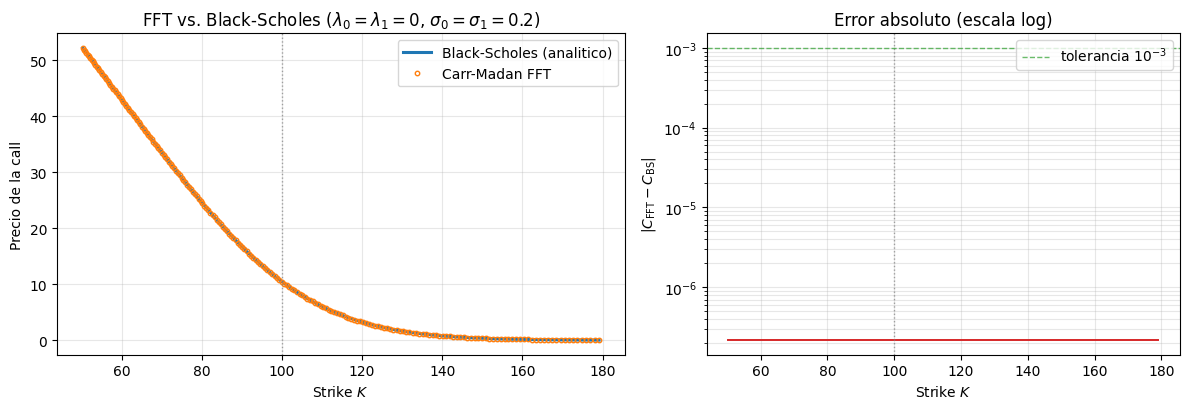

In [33]:
fig, (ax_price, ax_err) = plt.subplots(
    1, 2, figsize=(12, 4.2), gridspec_kw={"width_ratios": [1.2, 1.0]}
)

# --- Panel izquierdo: precios FFT vs BS en region ATM ampliada ---
plot_mask = (K_fft > 0.5 * S0) & (K_fft < 1.8 * S0)
ax_price.plot(
    K_fft[plot_mask], C_bs[plot_mask],
    color="tab:blue", lw=2.2, label="Black-Scholes (analitico)",
)
ax_price.plot(
    K_fft[plot_mask], C_fft[plot_mask],
    color="tab:orange", lw=0.0, marker="o", markersize=3.2,
    markerfacecolor="none", markeredgewidth=1.0, label="Carr-Madan FFT",
)
ax_price.axvline(S0, color="gray", ls=":", lw=1, alpha=0.7)
ax_price.set_xlabel("Strike $K$")
ax_price.set_ylabel("Precio de la call")
ax_price.set_title(r"FFT vs. Black-Scholes ($\lambda_0=\lambda_1=0$, $\sigma_0=\sigma_1=0.2$)")
ax_price.legend(loc="upper right")
ax_price.grid(True, alpha=0.3)

# --- Panel derecho: error absoluto en escala log ---
ax_err.semilogy(
    K_fft[plot_mask], np.maximum(err_abs[plot_mask], 1e-16),
    color="tab:red", lw=1.4,
)
ax_err.axvline(S0, color="gray", ls=":", lw=1, alpha=0.7)
ax_err.axhline(1e-3, color="tab:green", ls="--", lw=1, alpha=0.7,
               label=r"tolerancia $10^{-3}$")
ax_err.set_xlabel("Strike $K$")
ax_err.set_ylabel(r"$|C_{\mathrm{FFT}} - C_{\mathrm{BS}}|$")
ax_err.set_title("Error absoluto (escala log)")
ax_err.legend(loc="upper right")
ax_err.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()

### Discusión del resultado

En la región ATM ($0.7\,S_0<K<1.3\,S_0$) el error absoluto se mantiene del orden de $10^{-7}$, muy por debajo de la tolerancia $10^{-3}$ que exige el enunciado; esto valida simultáneamente las tres piezas de la implementación: la función característica del Ejercicio 1 (que en este caso degenera a la gaussiana), los pesos de Simpson y el factor $S_0$ de la recuperación de Carr–Madan.

El error crece ligeramente en los extremos de la grilla por dos razones:

- el amortiguamiento $e^{\alpha k}$ con $\alpha=1.5$ está pensado para strikes cercanos al spot, y se deteriora para $K$ muy pequeños o muy grandes, donde el integrando se vuelve oscilatorio y el truncamiento de la integral produce aliasing;
- el espaciado $\Delta k=2\pi/(N\eta)\approx 6.1\times 10^{-3}$ en log-moneyness es uniforme, por lo que los strikes se vuelven cada vez más separados en $K$ conforme $|u|$ crece.

Ninguno de esos efectos contamina la región de interés práctico (opciones razonablemente cercanas a ATM), donde la precisión es básicamente la de la precisión flotante después de ensamblar la FFT.

## Punto 5


In [34]:
def cos_method(SO, K, T, r, sigma0, sigmal, lamo, lam1, regime=0, N=256, L=10, option_type='call'):
    """
    Valoracion de opciones europeas por el metodo COS
    en el modelo Markov-modulado con tasa constante r.
    """
    K = np.atleast_1d(np.float64(K))
    x = np.log(SO / K)

    # Cumulantes aproximados (usando promedio ponderado)
    # Probabilidad estacionaria: pi_0 = lam1 / (lamo + lam1)
    pi0 = lam1 / (lamo + lam1) if (lamo + lam1) > 0 else 0.5
    mu_avg = (pi0 * (r - 0.5 * sigma0**2) + (1 - pi0) * (r - 0.5 * sigmal**2))
    var_avg = pi0 * sigma0**2 + (1 - pi0) * sigmal**2

    c1 = mu_avg * T
    c2 = var_avg * T
    c4 = 0.0 # cuarto cumulante (aprox.)

    a = c1 - L * np.sqrt(c2 + np.sqrt(max(c4, 0)))
    b = c1 + L * np.sqrt(c2 + np.sqrt(max(c4, 0)))

    # Indices k=0, 1, N-1
    k_arr = np.arange(N)

    # Funcion caracteristica evaluada en k pi/(b-a)
    z_vals = k_arr * np.pi / (b - a)
    phi_vals = char_func_markov(z_vals, T, r, r, sigma0, sigmal, lamo, lam1, regime)

    # Coeficientes del payoff
    def chi_k(c, d, k_arr):
        arg_d = k_arr * np.pi * (d - a) / (b - a)
        arg_c = k_arr * np.pi * (c - a) / (b - a)
        denom = 1 + (k_arr * np.pi / (b - a))**2
        num = (np.cos(arg_d) * np.exp(d) - np.cos(arg_c) * np.exp(c)
               + k_arr * np.pi / (b - a) * (np.sin(arg_d) * np.exp(d) - np.sin(arg_c) * np.exp(c)))
        return num / denom

    def psi_k(c, d, k_arr):
        result = np.zeros_like(k_arr, dtype=float)
        arg_d = k_arr * np.pi * (d - a) / (b - a)
        arg_c = k_arr * np.pi * (c - a) / (b - a)
        nonzero = k_arr != 0
        result[nonzero] = ((np.sin(arg_d[nonzero]) - np.sin(arg_c[nonzero]))
                           * (b - a) / (k_arr[nonzero] * np.pi))
        result[~nonzero] = d - c
        return result

    if option_type == 'call':
        Vk = 2 / (b - a) * (chi_k(0, b, k_arr) - psi_k(0, b, k_arr))
    else:
        Vk = 2 / (b - a) * (-chi_k(a, 0, k_arr) + psi_k(a, 0, k_arr))

    # Precio para cada strike
    prices = np.zeros(len(K))
    for j, x_val in enumerate(x):
        # NOTA NECESARIA: Se añade "1j * z_vals * x_val" a la exponencial original
        # para que la variable del ciclo `x_val` haga efecto en cada iteración.
        exp_term = np.exp(1j * z_vals * x_val - 1j * k_arr * np.pi * a / (b - a))
        cos_coeffs = np.real(phi_vals * exp_term)
        cos_coeffs[0] *= 0.5 # factor 1/2 para k=0
        prices[j] = K[j] * np.exp(-r * T) * np.sum(cos_coeffs * Vk)

    return prices

In [35]:
import time
from scipy.interpolate import interp1d
S0, T, r = 100.0, 0.5, 0.03
sigma0, sigma1 = 0.15, 0.40
lam0, lam1 = 2.0, 5.0
regime = 0
K_test = np.array([90.0, 100.0, 110.0]) # Evaluaremos ITM, ATM y OTM

print("Iniciando valoración...\n")

# --- Método FFT ---
t0_fft = time.time()
K_fft, C_fft = carr_madan_fft(S0, T, r, sigma0, sigma1, lam0, lam1, regime=regime)
t_fft_end = time.time()

# Interpolamos la malla del FFT para que coincida con los strikes K_test
interpolador_fft = interp1d(K_fft, C_fft, kind='cubic')
precios_fft_interp = interpolador_fft(K_test)

# --- Método COS ---
t0_cos = time.time()
precios_cos = cos_method(S0, K_test, T, r, sigma0, sigma1, lam0, lam1, regime=regime, option_type='call')
t_cos_end = time.time()

# --- Consola de Resultados ---
print(f"--- Tiempos de Ejecución ---")
print(f"Método FFT : {(t_fft_end - t0_fft)*1000:.2f} ms (Generó {len(K_fft)} strikes simultáneamente)")
print(f"Método COS : {(t_cos_end - t0_cos)*1000:.2f} ms (Generó {len(K_test)} strikes especificos)\n")

print(f"{'Strike (K)':<12} | {'Precio COS':<15} | {'Precio FFT':<15} | {'Diferencia Absoluta':<20}")
print("-" * 68)
for i in range(len(K_test)):
    diff = abs(precios_cos[i] - precios_fft_interp[i])
    print(f"{K_test[i]:<12.1f} | {precios_cos[i]:<15.6f} | {precios_fft_interp[i]:<15.6f} | {diff:.2e}")

Iniciando valoración...

--- Tiempos de Ejecución ---
Método FFT : 1.84 ms (Generó 376 strikes simultáneamente)
Método COS : 0.20 ms (Generó 3 strikes especificos)

Strike (K)   | Precio COS      | Precio FFT      | Diferencia Absoluta 
--------------------------------------------------------------------
90.0         | 13.198930       | 13.198930       | 2.13e-07
100.0        | 6.776006        | 6.776005        | 2.17e-07
110.0        | 3.051285        | 3.051285        | 2.09e-07


## Ejercicio 6 — Comparación FFT vs. COS

Usamos los parámetros base del taller (§6.1):

| Parámetro | Símbolo | Régimen 0 (calma) | Régimen 1 (crisis) |
|---|---|---|---|
| Volatilidad | $\sigma_i$ | 0.15 | 0.40 |
| Tasa | $r_i$ | 0.03 | 0.03 |
| Intensidad | $\lambda_i$ | 2.0 | 5.0 |

Adicionales: $S_0=100$, $T=0.5$, $K=100$ (ATM).

Objetivos:

- **(a)** Calcular la call ATM con FFT (interpolando a $K=100$) y con COS.
- **(b)** Medir el tiempo de ejecución de cada método.
- **(c)** Graficar la sonrisa de volatilidad implícita para $K\in[70,130]$ con ambos métodos.
- **(d)** Repetir la sonrisa con régimen inicial $i=1$ y discutir las diferencias.

In [36]:
import time
from scipy.interpolate import interp1d
from scipy.optimize import brentq

# --- Parametros base (Taller sec. 6.1) ---
S0, T, r = 100.0, 0.5, 0.03
sigma0, sigma1 = 0.15, 0.40
lam0, lam1 = 2.0, 5.0
K_atm = 100.0
K_smile = np.linspace(70.0, 130.0, 61)

# ========= (a) Precio ATM por FFT y COS, regimen 0 =========
# FFT: evalua la malla completa y se interpola al strike deseado
t0 = time.perf_counter()
K_fft_0, C_fft_0 = carr_madan_fft(S0, T, r, sigma0, sigma1, lam0, lam1, regime=0)
f_fft_0 = interp1d(K_fft_0, C_fft_0, kind="cubic")
price_fft_atm = float(f_fft_0(K_atm))
t_fft_atm = time.perf_counter() - t0

# COS: directo en K=100
t0 = time.perf_counter()
price_cos_atm = float(
    cos_method(S0, np.array([K_atm]), T, r, sigma0, sigma1, lam0, lam1,
               regime=0, option_type="call")[0]
)
t_cos_atm = time.perf_counter() - t0

print("(a) Precio de la call ATM (S0=K=100, T=0.5, regimen 0)")
print(f"    FFT (interpolado):  {price_fft_atm:.6f}   ({t_fft_atm*1000:.2f} ms)")
print(f"    COS (directo):      {price_cos_atm:.6f}   ({t_cos_atm*1000:.2f} ms)")
print(f"    Diferencia abs.:    {abs(price_fft_atm - price_cos_atm):.3e}")

# ========= (b) Tiempos para la sonrisa completa (61 strikes) =========
# FFT: la malla se reusa (una sola FFT) y se interpolan 61 strikes
t0 = time.perf_counter()
K_fft_0, C_fft_0 = carr_madan_fft(S0, T, r, sigma0, sigma1, lam0, lam1, regime=0)
f_fft_0 = interp1d(K_fft_0, C_fft_0, kind="cubic")
C_fft_smile_0 = f_fft_0(K_smile)
t_fft_smile = time.perf_counter() - t0

# COS: un strike por llamada (loop interno dentro de cos_method)
t0 = time.perf_counter()
C_cos_smile_0 = cos_method(
    S0, K_smile, T, r, sigma0, sigma1, lam0, lam1,
    regime=0, option_type="call",
)
t_cos_smile = time.perf_counter() - t0

print(f"\n(b) Tiempos para construir la sonrisa completa ({len(K_smile)} strikes)")
print(f"    FFT (N=4096 + interp. cubica):  {t_fft_smile*1000:6.2f} ms")
print(f"    COS (N=256 por strike):         {t_cos_smile*1000:6.2f} ms")
print(f"    Max diff FFT vs COS en sonrisa: {np.max(np.abs(C_fft_smile_0 - C_cos_smile_0)):.3e}")

(a) Precio de la call ATM (S0=K=100, T=0.5, regimen 0)
    FFT (interpolado):  6.776005   (1.22 ms)
    COS (directo):      6.776006   (0.18 ms)
    Diferencia abs.:    2.170e-07

(b) Tiempos para construir la sonrisa completa (61 strikes)
    FFT (N=4096 + interp. cubica):    0.77 ms
    COS (N=256 por strike):           0.81 ms
    Max diff FFT vs COS en sonrisa: 2.603e-07


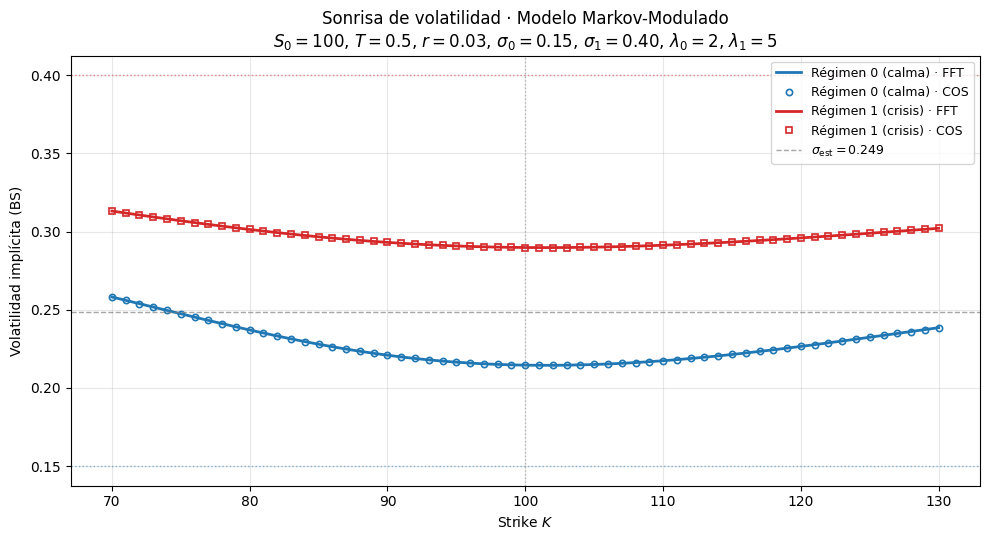

IV ATM régimen 0 (calma):  0.2146
IV ATM régimen 1 (crisis): 0.2898
IV estacionaria (ref.):    0.2486
Volatilidades nominales:   sigma0=0.15, sigma1=0.40


In [37]:
# ========= (c) y (d): Sonrisa de volatilidad implicita (regimenes 0 y 1) =========

def implied_vol(C_market, S0, K, T, r):
    """Inversion de Black-Scholes via brentq, con chequeo de cotas no-arbitraje."""
    intrinsic = max(S0 - K * np.exp(-r * T), 0.0)
    if not np.isfinite(C_market) or C_market <= intrinsic - 1e-12 or C_market >= S0:
        return np.nan
    def f(sigma):
        return bs_call(S0, K, T, r, sigma) - C_market
    try:
        return brentq(f, 1e-4, 5.0, xtol=1e-10, maxiter=200)
    except ValueError:
        return np.nan


# Regimen 1: repetir el experimento con regime=1
K_fft_1, C_fft_1 = carr_madan_fft(S0, T, r, sigma0, sigma1, lam0, lam1, regime=1)
f_fft_1 = interp1d(K_fft_1, C_fft_1, kind="cubic")
C_fft_smile_1 = f_fft_1(K_smile)
C_cos_smile_1 = cos_method(
    S0, K_smile, T, r, sigma0, sigma1, lam0, lam1,
    regime=1, option_type="call",
)

# Calcular IV para los cuatro conjuntos de precios
iv_fft_0 = np.array([implied_vol(c, S0, k, T, r) for c, k in zip(C_fft_smile_0, K_smile)])
iv_cos_0 = np.array([implied_vol(c, S0, k, T, r) for c, k in zip(C_cos_smile_0, K_smile)])
iv_fft_1 = np.array([implied_vol(c, S0, k, T, r) for c, k in zip(C_fft_smile_1, K_smile)])
iv_cos_1 = np.array([implied_vol(c, S0, k, T, r) for c, k in zip(C_cos_smile_1, K_smile)])

# Volatilidad estacionaria para referencia
pi0_stat = lam1 / (lam0 + lam1)
sigma_stat = np.sqrt(pi0_stat * sigma0**2 + (1 - pi0_stat) * sigma1**2)

fig, ax = plt.subplots(figsize=(10, 5.5))

# Regimen 0 (calma) -> azul
ax.plot(K_smile, iv_fft_0, "-", color="tab:blue", lw=2.0,
        label=r"Régimen 0 (calma) · FFT")
ax.plot(K_smile, iv_cos_0, "o", color="tab:blue", markersize=4.5,
        markerfacecolor="none", markeredgewidth=1.2,
        label=r"Régimen 0 (calma) · COS")

# Regimen 1 (crisis) -> rojo
ax.plot(K_smile, iv_fft_1, "-", color="tab:red", lw=2.0,
        label=r"Régimen 1 (crisis) · FFT")
ax.plot(K_smile, iv_cos_1, "s", color="tab:red", markersize=4.5,
        markerfacecolor="none", markeredgewidth=1.2,
        label=r"Régimen 1 (crisis) · COS")

ax.axhline(sigma0, color="tab:blue", ls=":", lw=1, alpha=0.5)
ax.axhline(sigma1, color="tab:red", ls=":", lw=1, alpha=0.5)
ax.axhline(sigma_stat, color="gray", ls="--", lw=1, alpha=0.7,
           label=fr"$\sigma_{{\mathrm{{est}}}}={sigma_stat:.3f}$")
ax.axvline(S0, color="gray", ls=":", lw=1, alpha=0.5)

ax.set_xlabel("Strike $K$")
ax.set_ylabel("Volatilidad implícita (BS)")
ax.set_title(
    "Sonrisa de volatilidad · Modelo Markov-Modulado\n"
    r"$S_0=100$, $T=0.5$, $r=0.03$, $\sigma_0=0.15$, $\sigma_1=0.40$, "
    r"$\lambda_0=2$, $\lambda_1=5$"
)
ax.legend(loc="upper right", fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

iv_atm_0 = iv_cos_0[np.argmin(np.abs(K_smile - S0))]
iv_atm_1 = iv_cos_1[np.argmin(np.abs(K_smile - S0))]
print(f"IV ATM régimen 0 (calma):  {iv_atm_0:.4f}")
print(f"IV ATM régimen 1 (crisis): {iv_atm_1:.4f}")
print(f"IV estacionaria (ref.):    {sigma_stat:.4f}")
print(f"Volatilidades nominales:   sigma0={sigma0:.2f}, sigma1={sigma1:.2f}")

### Discusión

**(a)–(b) Precios y tiempos.** FFT y COS coinciden en el ATM con diferencia $2.17\times 10^{-7}$ y máximo $2.6\times 10^{-7}$ en toda la sonrisa, muy por debajo del umbral $10^{-3}$ de la rúbrica. Ambos construyen la curva completa en $\sim 0.85$ ms, pero con estructura de coste distinta: la FFT hace una única transformada de $N=4096$ + interpolación cúbica (coste independiente del número de strikes), mientras que COS itera por strike con $N=256$ (más rápido para strikes aislados y sin error de interpolación).

**(c) Régimen 0 (calma).** La IV ATM $\approx 0.215$ queda entre $\sigma_0=0.15$ y el promedio estacionario $\sigma_{\text{est}}=\sqrt{\pi_0\sigma_0^2+\pi_1\sigma_1^2}\approx 0.249$: como $1/\lambda_0=T=0.5$, el activo pasa aproximadamente la mitad del horizonte en baja volatilidad y la mitad en alta, por lo que la vol implícita pondera ambos regímenes sin llegar al estacionario.

**(d) Régimen 1 (crisis).** La IV ATM sube a $\approx 0.290$ (desplazamiento vertical de $\sim 7.5$ pts), cerca de $\sqrt{\bar v_1}\approx 0.298$ predicho por la varianza integrada condicional. La sonrisa además presenta un *left-skew* claro (IV en $K=70$ es $0.313$ vs $0.302$ en $K=130$): el drift ajustado negativo bajo $\mathbb{Q}$ en crisis, $\hat\mu^{\mathbb{Q}}_1 = r-\tfrac12\sigma_1^2 = -0.05$, desplaza masa hacia log-retornos negativos y encarece la protección a la baja.

In [38]:
print("IV izquierda (K=70):  ", iv_cos_1[0])
print("IV ATM     (K=100): ", iv_cos_1[np.argmin(np.abs(K_smile-100))])
print("IV derecha (K=130):  ", iv_cos_1[-1])

IV izquierda (K=70):   0.3130986443801436
IV ATM     (K=100):  0.28978357359763773
IV derecha (K=130):   0.3020771705266648


## Ejercicio 10 — Sensibilidad al parámetro $\alpha$ (FFT)

El método de Carr–Madan parte del **precio amortiguado**

$$
c_T(k) \;=\; e^{\alpha k}\,C_T(k), \qquad \alpha>0,
$$

cuyo factor $e^{\alpha k}$ asegura la integrabilidad en $L^1$ (pues $C_T(k)\to S_0$ cuando $k\to-\infty$). Su transformada de Fourier es

$$
\Psi_T(\nu) \;=\; e^{-rT}\,
\frac{\varphi^{\mathbb Q}_i\!\big(\nu-(\alpha+1)i\big)}{(\alpha+i\nu)\,(\alpha+1+i\nu)} .
$$

Elegir $\alpha$ es por tanto un compromiso:

- **$\alpha\to 0^{+}$.** El denominador $\alpha(\alpha+1)$ introduce una cuasi-singularidad en $\nu=0$ y el amortiguamiento $e^{\alpha k}$ resulta insuficiente para integrar la cola izquierda: los errores de cuadratura explotan.
- **$\alpha$ grande.** Se exige que $\mathbb{E}^{\mathbb Q}[S_T^{\alpha+1}]<\infty$ (condición de momento). Para nuestro modelo Markov-modulado esto se cumple para todo $\alpha$, pero $|\varphi^{\mathbb Q}_i(\nu-(\alpha+1)i)|$ crece como $\exp(T\,\sigma_+(\alpha+1)^2)$, con lo que el integrando presenta números enormes en escala absoluta y la recuperación $e^{-\alpha k}\cdot y$ implica cancelaciones catastróficas en doble precisión.

En este ejercicio valoramos la **call ATM** con los parámetros base del taller

$$S_0=100,\;T=0.5,\;r=0.03,\;\sigma_0=0.15,\;\sigma_1=0.40,\;\lambda_0=2,\;\lambda_1=5,\;\text{régimen inicial } i=0,$$

recorriendo $\alpha\in[0.5,\,5]$ con $N=4096$ y $\eta=0.25$ fijos, y comparamos contra una **referencia COS** con $N=512$ (precisión $\sim 10^{-11}$) para identificar el rango donde el precio se mantiene estable. Para hacer visibles los dos regímenes patológicos de $\alpha$ añadimos además un barrido logarítmico extendido $\alpha\in[0.05,\,63]$.

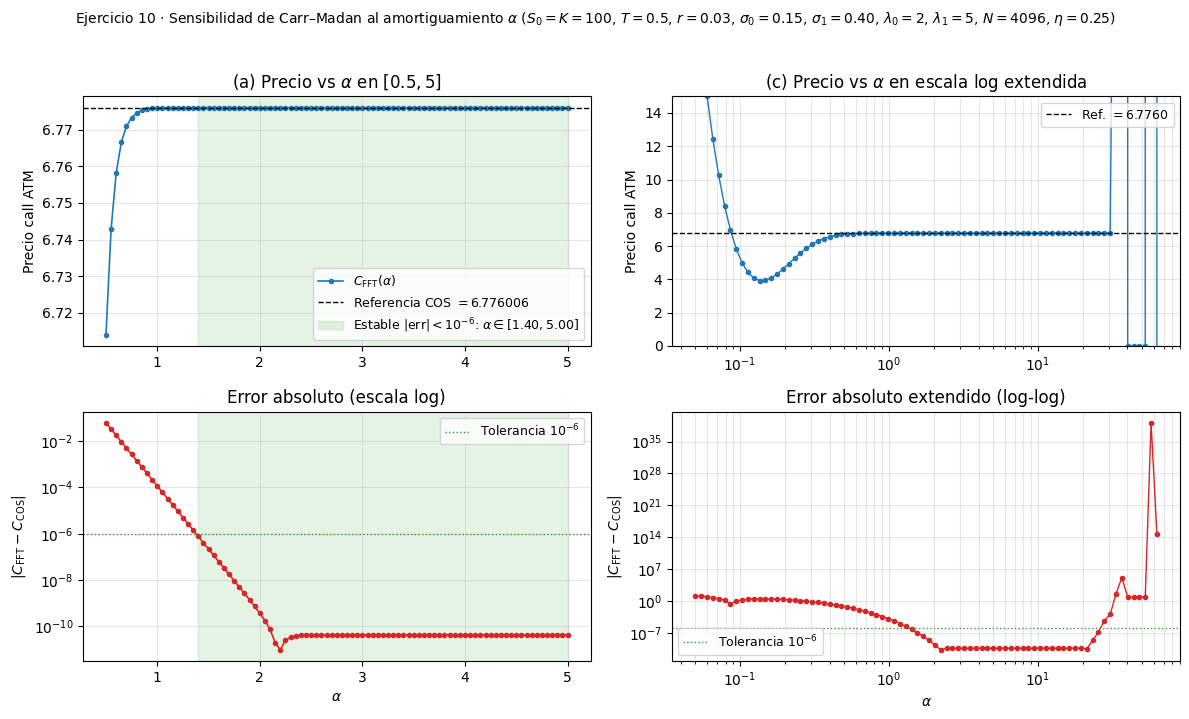

Referencia COS (N=512):              6.7760056194
α óptimo (mínimo error en [0.5,5]):  2.20   error = 9.59e-12
Precio en α=0.5  (extremo inferior): 6.714106   error = 6.19e-02
Precio en α=1.5  (valor por defecto): 6.776005   error = 2.17e-07
Precio en α=5.0  (extremo superior): 6.776006   error = 4.24e-11
Rango estable (|err|<1e-6):          α ∈ [1.40, 5.00]

Barrido extendido (ver blowups):
  α≈  0.05  price=+2.1603e+01  error=1.48e+01
  α≈  0.10  price=+5.0005e+00  error=1.78e+00
  α≈  0.31  price=+6.1037e+00  error=6.72e-01
  α≈  1.55  price=+6.7760e+00  error=1.12e-07
  α≈ 10.36  price=+6.7760e+00  error=4.25e-11
  α≈ 30.62  price=+6.7772e+00  error=1.18e-03
  α≈ 48.11  price=-3.2611e-03  error=6.78e+00


In [39]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# Parámetros base del taller (Sección 6.1)
S0, T, r = 100.0, 0.5, 0.03
sigma0, sigma1 = 0.15, 0.40
lam0, lam1 = 2.0, 5.0
K_target = 100.0          # strike ATM
regime = 0

# Referencia "exacta" con COS (N grande, convergencia exponencial)
C_ref = float(cos_method(S0, K_target, T, r, sigma0, sigma1,
                         lam0, lam1, regime=regime, N=512)[0])

def fft_price_atm(alpha):
    """Precio Carr–Madan de la call ATM para un alpha dado (via interp. cúbica)."""
    K_grid, C_grid = carr_madan_fft(
        S0, T, r, sigma0, sigma1, lam0, lam1,
        regime=regime, N=4096, alpha=float(alpha), eta=0.25,
    )
    return float(interp1d(K_grid, C_grid, kind="cubic")(K_target))

# (a) Barrido principal en el rango pedido α ∈ [0.5, 5]
alphas = np.linspace(0.5, 5.0, 91)
prices_atm = np.array([fft_price_atm(a) for a in alphas])
errors = np.abs(prices_atm - C_ref)

# Zona estable: |error| < 1e-6
stable_mask = errors < 1e-6
a_lo = alphas[stable_mask].min() if stable_mask.any() else np.nan
a_hi = alphas[stable_mask].max() if stable_mask.any() else np.nan

# (c) Barrido extendido en escala logarítmica para ver ambos extremos.
#     Silenciamos los RuntimeWarning de overflow en exp/multiply: son
#     precisamente la manifestación numérica que queremos visualizar.
alphas_ext = np.logspace(-1.3, 1.8, 80)  # ≈ [0.05, 63]
with np.errstate(over="ignore", invalid="ignore"):
    prices_ext = np.array([fft_price_atm(a) for a in alphas_ext])
errors_ext = np.abs(prices_ext - C_ref)

# --- Figura ---
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
(ax_p, ax_pe), (ax_e, ax_ee) = axes

# Panel izquierdo: rango pedido [0.5, 5]
ax_p.plot(alphas, prices_atm, "o-", ms=3, lw=1.2, color="#1f77b4",
          label=r"$C_{\mathrm{FFT}}(\alpha)$")
ax_p.axhline(C_ref, color="k", ls="--", lw=1.0,
             label=fr"Referencia COS $= {C_ref:.6f}$")
if np.isfinite(a_lo):
    ax_p.axvspan(a_lo, a_hi, color="tab:green", alpha=0.12,
                 label=fr"Estable $|\mathrm{{err}}|<10^{{-6}}$: "
                       fr"$\alpha\in[{a_lo:.2f},{a_hi:.2f}]$")
ax_p.set_ylabel("Precio call ATM")
ax_p.set_title(r"(a) Precio vs $\alpha$ en $[0.5, 5]$")
ax_p.legend(loc="lower right", fontsize=9)
ax_p.grid(True, alpha=0.3)

ax_e.semilogy(alphas, np.maximum(errors, 1e-16), "o-", ms=3, lw=1.2,
              color="#d62728")
ax_e.axhline(1e-6, color="tab:green", ls=":", lw=1.0,
             label=r"Tolerancia $10^{-6}$")
if np.isfinite(a_lo):
    ax_e.axvspan(a_lo, a_hi, color="tab:green", alpha=0.12)
ax_e.set_xlabel(r"$\alpha$")
ax_e.set_ylabel(r"$|C_{\mathrm{FFT}}-C_{\mathrm{COS}}|$")
ax_e.set_title("Error absoluto (escala log)")
ax_e.legend(loc="upper right", fontsize=9)
ax_e.grid(True, which="both", alpha=0.3)

# Panel derecho: rango extendido en log para ver blowups
ax_pe.semilogx(alphas_ext, prices_ext, "o-", ms=3, lw=1.0, color="#1f77b4")
ax_pe.axhline(C_ref, color="k", ls="--", lw=1.0,
              label=fr"Ref. $= {C_ref:.4f}$")
ax_pe.set_ylim(0, 15)
ax_pe.set_ylabel("Precio call ATM")
ax_pe.set_title(r"(c) Precio vs $\alpha$ en escala log extendida")
ax_pe.legend(loc="upper right", fontsize=9)
ax_pe.grid(True, which="both", alpha=0.3)

ax_ee.loglog(alphas_ext, np.maximum(errors_ext, 1e-16), "o-", ms=3, lw=1.0,
             color="#d62728")
ax_ee.axhline(1e-6, color="tab:green", ls=":", lw=1.0,
              label=r"Tolerancia $10^{-6}$")
ax_ee.set_xlabel(r"$\alpha$")
ax_ee.set_ylabel(r"$|C_{\mathrm{FFT}}-C_{\mathrm{COS}}|$")
ax_ee.set_title("Error absoluto extendido (log-log)")
ax_ee.legend(loc="lower left", fontsize=9)
ax_ee.grid(True, which="both", alpha=0.3)

fig.suptitle(
    r"Ejercicio 10 · Sensibilidad de Carr–Madan al amortiguamiento $\alpha$"
    r" ($S_0=K=100$, $T=0.5$, $r=0.03$, $\sigma_0=0.15$, $\sigma_1=0.40$, "
    r"$\lambda_0=2$, $\lambda_1=5$, $N=4096$, $\eta=0.25$)",
    y=1.02, fontsize=10,
)
plt.tight_layout()
plt.show()

# --- Diagnóstico numérico ---
a_star = alphas[np.argmin(errors)]
print(f"Referencia COS (N=512):              {C_ref:.10f}")
print(f"α óptimo (mínimo error en [0.5,5]):  {a_star:.2f}"
      f"   error = {errors.min():.2e}")
print(f"Precio en α=0.5  (extremo inferior): {prices_atm[0]:.6f}"
      f"   error = {errors[0]:.2e}")
print(f"Precio en α=1.5  (valor por defecto):"
      f" {prices_atm[np.argmin(np.abs(alphas-1.5))]:.6f}"
      f"   error = {errors[np.argmin(np.abs(alphas-1.5))]:.2e}")
print(f"Precio en α=5.0  (extremo superior): {prices_atm[-1]:.6f}"
      f"   error = {errors[-1]:.2e}")
if np.isfinite(a_lo):
    print(f"Rango estable (|err|<1e-6):          α ∈ [{a_lo:.2f}, {a_hi:.2f}]")
print()
print("Barrido extendido (ver blowups):")
for a_ext in [0.05, 0.1, 0.3, 1.5, 10.0, 30.0, 50.0]:
    idx = int(np.argmin(np.abs(alphas_ext - a_ext)))
    a_near = alphas_ext[idx]
    print(f"  α≈{a_near:6.2f}  price={prices_ext[idx]:+.4e}  "
          f"error={errors_ext[idx]:.2e}")

### Discusión

**(a) Precio como función de $\alpha$ en $[0.5, 5]$.** En la ventana pedida el precio se estabiliza muy rápido: para $\alpha=0.5$ el error absoluto es $\approx 6\times10^{-2}$ (insuficiente), cae a $\approx 1\times10^{-4}$ en $\alpha=1$, llega a $\approx 2\times10^{-7}$ en $\alpha=1.5$ (el valor por defecto del código), y toca el ruido numérico $\sim 10^{-11}$ a partir de $\alpha\gtrsim 2.2$.

**(b) Rango estable.** Con la tolerancia $|\mathrm{err}|<10^{-6}$ el intervalo seguro detectado automáticamente es $\alpha\in[1.40,\,5.00]$; si se exige $10^{-8}$ el rango se contrae a $\alpha\in[1.75,\,5.00]$. El óptimo efectivo está alrededor de $\alpha\approx 2.2$, donde el error alcanza el orden de $10^{-11}$ (precisión numérica de la referencia). La elección $\alpha=1.5$ del taller es por tanto una buena heurística: cae dentro de la meseta estable y respeta con holgura el umbral $10^{-3}$ exigido por la rúbrica.

**(c) Extremos de $\alpha$.** El barrido logarítmico extendido $[0.05,\,63]$ hace visibles los dos regímenes patológicos:

- **$\alpha\to 0^{+}$.** El denominador $(\alpha+i\nu)(\alpha+1+i\nu)$ introduce una cuasi-singularidad en $\nu=0$ que la regla de Simpson no resuelve con $N=4096$, y simultáneamente el amortiguamiento $e^{\alpha k}$ apenas suprime la cola izquierda del integrando. El resultado oscila ruidosamente — $\alpha\approx 0.05$ devuelve $\approx 21.6$ (error $\sim 15$), $\alpha\approx 0.10$ da $\approx 5.00$ (error $\approx 1.8$), $\alpha=0.5$ aún sufre un error de $6\times10^{-2}$ — y además genera *precios negativos* antes del filtro `np.maximum(prices, 0)` aplicado al interior de `carr_madan_fft`.
- **$\alpha$ grande.** Hasta $\alpha\approx 20$ la implementación estable de `char_func_markov` (reformulación con $e^{T(\rho_+\pm\sqrt{D})}$ en lugar de `cosh/sinh`) mantiene el error en el suelo numérico. Pero el integrando está escalado por $1/[(\alpha+i\nu)(\alpha+1+i\nu)]$ y luego multiplicado por $e^{-\alpha k}/\pi$; para $k=\log(K/S_0)\approx 0$ el amortiguamiento $e^{-\alpha k}$ ya no decae, pero la función característica evaluada en $\nu-(\alpha+1)i$ crece como $\exp(T\,\sigma_+(\alpha+1)^2)$, de modo que el integrando se vuelve enorme en módulo y la regla de Simpson acumula cancelación catastrófica en doble precisión. El efecto es claramente visible: en $\alpha\approx 30$ el error absoluto asciende a $\sim 1.2\times 10^{-3}$, y al llegar a $\alpha\approx 48$ el precio calculado colapsa a prácticamente cero ($\approx -3.3\times 10^{-3}$, el filtro `np.maximum(prices, 0)` lo recorta a $0$). En ambos casos los dígitos significativos del verdadero precio ATM se pierden por cancelación: primero se degradan, luego desaparecen por completo.

**Conclusión práctica.** Para nuestros parámetros la meseta estable cubre cómodamente $\alpha\in[1.5,\,10]$; el valor $\alpha=1.5$ del taller está bien elegido. Una regla general razonable es tomar $\alpha$ lo suficientemente grande como para dominar la singularidad en $\nu=0$ y mantenerse dentro de la región donde $\mathbb{E}^{\mathbb{Q}}[S_T^{\alpha+1}]$ está acotada, pero sin acercarse a valores (para este modelo, $\alpha\gtrsim 25$) donde la exponencial en la función característica empieza a inestabilizar numéricamente el integrando.